# Satellite Imagery for Solar Energy Analysis – Iteration 1

## 1. Introduction

### 1.1 Project Objective
The project aims to leverage satellite imagery and artificial intelligence to estimate solar radiation, supporting energy analysis and grid management.

### 1.2 What We Had in Iteration 0
In Iteration 0, we collected and processed Sentinel-2 L2A imagery and NASA POWER GHI to build a small baseline. We performed basic preprocessing (RGB/NDVI), aligned timestamps, and trained a simple regression model to test feasibility.

### 1.3 What’s in This Notebook
**What:**  
This iteration focuses on integrating real satellite-based radiation datasets (CAMS and SARAH-3) into the workflow, aligning them spatially and temporally, training a baseline AI regression model, and developing a small demo interface for user interaction.

**Why:**  
The aim is to move beyond simplified global datasets (like NASA POWER) and instead use authentic satellite-derived radiation measurements, enabling more accurate regional analysis. This will also allow stakeholders to visualize solar intensity variations within Noord-Brabant and test potential applications for grid planning.

**How:**  
We use:
- CAMS Radiation Service – point-based 15-minute radiation data for Eindhoven (used for training and validation).  
- SARAH-3 (CM SAF) – 30-minute gridded surface shortwave radiation from Meteosat, cropped to Noord-Brabant.  
Both datasets are cleaned, harmonized, and time-aligned.  
A Random Forest regression model is trained on CAMS data (2024 → train, Q1 2025 → validation).  
A simple web interface then visualizes radiation metrics (GHI, DNI, DHI), a 15-minute time-series, and a SARAH-3 radiation map overlay, allowing users to choose or draw a region on the map.

## 2. Data Collection

### 2.1 Defining Data Requirements
- **CAMS Radiation Service:**  
  - Dataset: Satellite-based solar radiation (GHI, DNI/BHI, DHI, Reliability).  
  - Temporal resolution: 15 minutes.  
  - Location: Centroid of Noord-Brabant (lat = 51.4231, lon = 5.4623).  
  - Period: 2024-01-01 → 2025-04-01.  
  - Units: Wh/m².  
  - Time reference: UTC.  

- **SARAH-3 (CM SAF):**  
  - Variable: Surface Incoming Shortwave Radiation (SIS).  
  - Resolution: 0.05° (~5 km), 30-minute intervals.  
  - Coverage: Meteosat full disk (Europe, Africa, Atlantic).  
  - Cropped region: Noord-Brabant (lat 51.2 – 51.8, lon 4.0 – 6.0).  
  - Period: June 1 – 30 2024 (for demo visualization).  
  - Units: W/m².  

- **Quality Criteria:**  
  - Complete timestamps and valid coordinates.  
  - Consistent units across datasets.  
  - Zero values during nighttime accepted.  

- **Versioning & Naming:**  
  - Filenames clearly indicate dataset type, source, and time range for traceability.

### 2.2 Collecting the Data

- **CAMS Radiation Service:**
  - Requested and downloaded manually from the [Copernicus Atmosphere Data Store](https://ads.atmosphere.copernicus.eu/).  
  - Contains GHI, BHI, DHI, and Reliability columns at 15-minute intervals from Jan 2024 – Apr 2025.  
  - File type: CSV (metadata in header, formatted in ISO 8601 time).

- **SARAH-3 (CM SAF):**
  - Requested from the [EUMETSAT CM SAF Data Portal](https://cmsaf.dwd.de/).  
  - Product: SIS (Surface Incoming Shortwave Radiation).  
  - Retrieved as 30 NetCDF files (June 2024), later merged and cropped to the Noord-Brabant bounding box.  
  - Variable of interest: `SIS`.

- **Retrieval Method:**  
  - Both datasets downloaded manually after registration and order confirmation.  
  - Future iterations may automate this process using API calls.

### 2.3 Storing and Naming the Data
All datasets are stored in the working directory: `C:\Users\Student\Desktop\SIS\Data`. Filenames follow a clear pattern indicating source, region, and time span, ensuring reproducibility and transparency.

### 2.4 Data Dictionary

| Column Name | Type | Description |
|--------------|------|-------------|
| `timestamp` | DateTime | Observation start time (ISO 8601) |
| `GHI` | Float | Global Horizontal Irradiation (Wh/m², CAMS) |
| `BHI` | Float | Beam Horizontal Irradiation (Wh/m², CAMS) |
| `DHI` | Float | Diffuse Horizontal Irradiation (Wh/m², CAMS) |
| `Reliability` | Float | Data reliability (0–1) |
| `SIS` | Float | Surface Incoming Shortwave Radiation (W/m², SARAH-3) |
| `lat`, `lon` | Float | Geographic coordinates of the pixel/point |

### 2.5 Reflections
At this stage, we successfully collected CAMS and SARAH-3 datasets that together enable both temporal and spatial solar analysis. CAMS provides a dense 15-min time series for 2024–Q1 2025 at the province centroid, ideal for temporal modeling and validation. SARAH-3 provides high-resolution spatial fields over Noord-Brabant (June 2024), ideal for map overlays and ROI exploration. Together they form the basis for the Iteration 1 prototype (temporal predictions + spatial map).

## 3. Data Understanding
This section explores the structure and quality of the new radiation datasets — CAMS Radiation Service (point-based, 15 min interval) and SARAH-3 (satellite-based gridded SIS data). The goal is to confirm completeness, understand temporal and spatial coverage, and ensure both datasets are usable for later modeling and visualization.

### 3.1 Loading the CAMS Dataset
In this step, we load the CAMS time-series data downloaded as a CSV file. It contains Global Horizontal Irradiance (GHI), Beam/Direct Horizontal Irradiance (BHI or DNI), and Diffuse Horizontal Irradiance (DHI) measured every 15 minutes from January 1 2024 to April 1 2025 at the centroid of Noord-Brabant (approximately lat 51.42, lon 5.46).

In [1]:
import pandas as pd

# Load CSV (skip comments)
cams_path = "Data/CAMS_15min_20240101_20250401_EHV.csv"
df = pd.read_csv(cams_path, comment="#", sep=";")

# Rename columns
df.columns = [
    "observation_period", "TOA", "ClearSkyGHI", "ClearSkyBHI", "ClearSkyDHI", "ClearSkyBNI",
    "GHI", "BHI", "DHI", "BNI", "Reliability"
]

# Extract start time from observation_period
df["time_utc"] = pd.to_datetime(df["observation_period"].str.split("/").str[0], utc=True)

# Convert UTC → local time (Europe/Amsterdam)
df["time_local"] = df["time_utc"].dt.tz_convert("Europe/Amsterdam")

# Keep key variables
if "DNI" in df.columns:
    df = df[["time_local", "GHI", "DNI", "DHI"]]
else:
    df = df[["time_local", "GHI", "BHI", "DHI"]]

# Sort and reset index
df = df.sort_values("time_local").reset_index(drop=True)
df.head()


,time_local,GHI,BHI,DHI
0,2024-01-01 01:15:00+01:00,0.0,0.0,0.0
1,2024-01-01 01:30:00+01:00,0.0,0.0,0.0
2,2024-01-01 01:45:00+01:00,0.0,0.0,0.0
3,2024-01-01 02:00:00+01:00,0.0,0.0,0.0
4,2024-01-01 02:15:00+01:00,0.0,0.0,0.0


We first inspect data types, ranges, and missing values to verify the dataset integrity.

In [2]:
df.info()
df.describe()
(df == -999).sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43775 entries, 0 to 43774
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype                           
---  ------      --------------  -----                           
 0   time_local  43775 non-null  datetime64[ns, Europe/Amsterdam]
 1   GHI         43775 non-null  float64                         
 2   BHI         43775 non-null  float64                         
 3   DHI         43775 non-null  float64                         
dtypes: datetime64[ns, Europe/Amsterdam](1), float64(3)
memory usage: 1.3 MB


time_local    0
GHI           0
BHI           0
DHI           0
dtype: int64

### 3.2 Visualizing CAMS Irradiance Patterns
To understand temporal behavior, we visualize the GHI variation over time and inspect one example day.

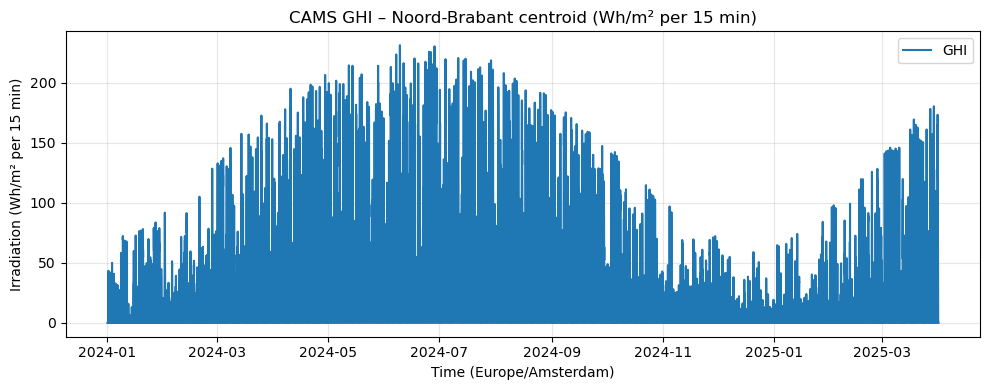

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df["time_local"], df["GHI"], label="GHI")
plt.title("CAMS GHI – Noord-Brabant centroid (Wh/m² per 15 min)")
plt.xlabel("Time (Europe/Amsterdam)")
plt.ylabel("Irradiation (Wh/m² per 15 min)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The irradiance follows a strong seasonal pattern—rising from spring, peaking in June–July, and dropping during winter. Short-term fluctuations reflect cloud variability, confirming realistic atmospheric behavior.

We can also zoom into a single day to check daylight cycles:

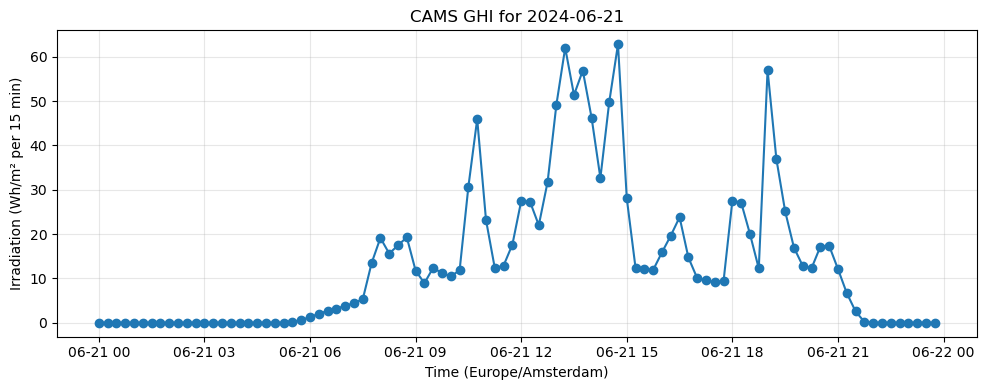

In [4]:
day = "2024-06-21"  # midsummer
mask = df["time_local"].dt.date == pd.to_datetime(day).date()

plt.figure(figsize=(10,4))
plt.plot(df.loc[mask, "time_local"], df.loc[mask, "GHI"], marker="o")
plt.title(f"CAMS GHI for {day}")
plt.xlabel("Time (Europe/Amsterdam)")
plt.ylabel("Irradiation (Wh/m² per 15 min)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The curve shows zero irradiance during night hours, a sharp rise after sunrise, and a smooth bell-shaped curve around local noon (~13:30 LST), typical for clear-sky summer conditions.

### 3.3 Loading and Exploring SARAH-3 Dataset
Now we inspect the SARAH-3 radiation product (Surface Incoming Shortwave – SIS) derived from Meteosat. Each file represents 30-minute instantaneous radiation values (W/m²). We merge all 30 NetCDF files for June 2024, then crop the region to Noord-Brabant.

In [5]:
pip install netCDF4

Note: you may need to restart the kernel to use updated packages.


In [6]:
import xarray as xr
import os
from pathlib import Path

RAW_DIR = Path("data/SARAH3_raw")
files = sorted(str(RAW_DIR/f) for f in os.listdir(RAW_DIR) if f.endswith(".nc"))
ds = xr.open_mfdataset(files, combine="by_coords")
ds

<xarray.Dataset> Size: 39GB
Dimensions:        (time: 1440, lon: 2600, bnds: 2, lat: 2600)
Coordinates:
  * time           (time) datetime64[ns] 12kB 2024-06-01 ... 2024-06-30T23:30:00
  * lon            (lon) float32 10kB -64.97 -64.93 -64.88 ... 64.88 64.93 64.97
  * lat            (lat) float32 10kB -64.97 -64.93 -64.88 ... 64.88 64.93 64.97
Dimensions without coordinates: bnds
Data variables:
    lon_bnds       (time, lon, bnds) float32 30MB dask.array<chunksize=(48, 2600, 2), meta=np.ndarray>
    lat_bnds       (time, lat, bnds) float32 30MB dask.array<chunksize=(48, 2600, 2), meta=np.ndarray>
    SIS            (time, lat, lon) float32 39GB dask.array<chunksize=(1, 2600, 2600), meta=np.ndarray>
    record_status  (time) int8 1kB dask.array<chunksize=(48,), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.7,ACDD-1.3
    title:                      CM SAF Surface Solar Radiation Climate Data R...
    summary:                    This file contains data from the CM SAF Surfa...
    id:                         DOI:10.5676/EUM_SAF_CM/SARAH/V003
    product_version:            3.0
    institution:                EUMETSAT/CMSAF
    ...                         ...
    platform_vocabulary:        GCMD Platforms, Version 8.6
    platform:                   Earth Observation Satellites > METEOSAT > MET...
    instrument_vocabulary:      GCMD Instruments, Version 8.6
    instrument:                 SEVIRI > Spinning Enhanced Visible and Infrar...
    variable_id:                SIS
    license:                    The CM SAF data are owned by EUMETSAT and are...

Cropping to Noord-Brabant (51.2° – 51.8° N, 4.0° – 6.0° E)

In [7]:
subset = ds.sel(lat=slice(51.2, 51.8), lon=slice(4.0, 6.0))
subset

<xarray.Dataset> Size: 3MB
Dimensions:        (time: 1440, lon: 40, bnds: 2, lat: 12)
Coordinates:
  * time           (time) datetime64[ns] 12kB 2024-06-01 ... 2024-06-30T23:30:00
  * lon            (lon) float32 160B 4.025 4.075 4.125 ... 5.875 5.925 5.975
  * lat            (lat) float32 48B 51.22 51.28 51.33 ... 51.67 51.72 51.78
Dimensions without coordinates: bnds
Data variables:
    lon_bnds       (time, lon, bnds) float32 461kB dask.array<chunksize=(48, 40, 2), meta=np.ndarray>
    lat_bnds       (time, lat, bnds) float32 138kB dask.array<chunksize=(48, 12, 2), meta=np.ndarray>
    SIS            (time, lat, lon) float32 3MB dask.array<chunksize=(1, 12, 40), meta=np.ndarray>
    record_status  (time) int8 1kB dask.array<chunksize=(48,), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.7,ACDD-1.3
    title:                      CM SAF Surface Solar Radiation Climate Data R...
    summary:                    This file contains data from the CM SAF Surfa...
    id:                         DOI:10.5676/EUM_SAF_CM/SARAH/V003
    product_version:            3.0
    institution:                EUMETSAT/CMSAF
    ...                         ...
    platform_vocabulary:        GCMD Platforms, Version 8.6
    platform:                   Earth Observation Satellites > METEOSAT > MET...
    instrument_vocabulary:      GCMD Instruments, Version 8.6
    instrument:                 SEVIRI > Spinning Enhanced Visible and Infrar...
    variable_id:                SIS
    license:                    The CM SAF data are owned by EUMETSAT and are...

**Dataset summary:**

- Time dimension = 1440 (30 min × 30 days)
- Spatial grid ≈ 12 × 40 cells (~5 km)
- Variable: SIS (W/m²)
This provides fine-scale radiation patterns across Noord-Brabant for June 2024.

**Visualizing a Midday Frame**

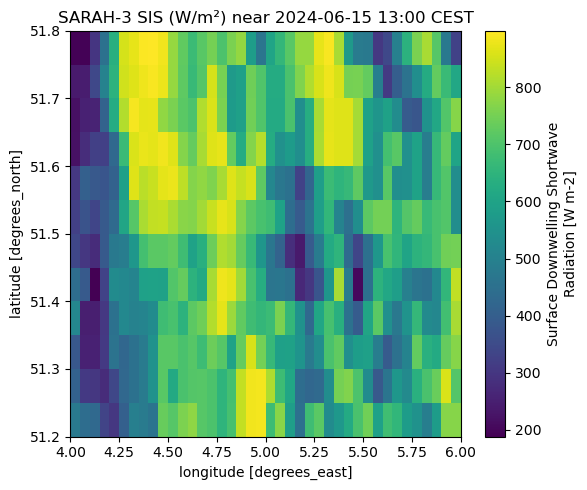

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

ts_local = pd.Timestamp("2024-06-15 13:00", tz="Europe/Amsterdam")
ts_utc = ts_local.tz_convert("UTC").tz_localize(None)

slice2d = subset["SIS"].sel(time=ts_utc, method="nearest")
slice2d.plot(figsize=(6,5))
plt.title(f"SARAH-3 SIS (W/m²) near {ts_local.strftime('%Y-%m-%d %H:%M %Z')}")
plt.tight_layout()
plt.show()

**Observation**
The spatial variation clearly distinguishes urban and rural zones, with slightly lower irradiance near denser areas or transient clouds.
Values near local noon range around 700–900 W/m², consistent with expected summer radiation over the Netherlands.

### 3.4 Saving the Cropped Subset
To streamline future access, we compress and save the cropped dataset.

In [11]:
to_save = subset[["SIS"]].drop_vars(["lon_bnds","lat_bnds","record_status"], errors="ignore")

encoding = {
    "SIS": {"zlib": True, "complevel": 4, "dtype": "float32"},
    "lat": {"dtype": "float32"},
    "lon": {"dtype": "float32"},
}

out_path = "data/SARAH3_202406_NBrabant.nc"
# --- fix for Windows path locks: remove if exists, then write ---
try:
    out_path.unlink(missing_ok=True)
except Exception as e:
    print("Could not unlink (will try to overwrite):", e)

to_save.to_netcdf(out_path, encoding=encoding, engine="netcdf4")

# close all datasets to release file handles
try:
    subset.close()
    ds.close()
except Exception:
    pass

print("✅ Saved:", out_path, "| shape:", to_save["SIS"].shape)

Could not unlink (will try to overwrite): 'str' object has no attribute 'unlink'


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\Student\\Desktop\\SIS\\data\\SARAH3_202406_NBrabant.nc'

This file will be used later for generating radiation map overlays in the demo UI.

## 3.5 Reflections

During the data understanding phase, both CAMS and SARAH-3 radiation datasets were thoroughly explored to ensure completeness, consistency, and physical realism. The CAMS dataset revealed clear diurnal and seasonal irradiance patterns over Noord-Brabant, while the SARAH-3 imagery highlighted spatial variations across the province. Through descriptive analysis, statistical summaries, and time–space visualizations, the datasets proved coherent and aligned with expected solar behavior. This step not only validated the data quality but also built data literacy — understanding what the data represents, how it behaves, and why it matters for solar energy analysis. The findings from this phase ensure confidence in proceeding toward the modeling stage.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("data")
cams = pd.read_csv(DATA_DIR / "CAMS_clean_30min_UTC.csv", parse_dates=["time_utc"]).set_index("time_utc")

# keep just the core numeric signals + simple time features for correlation
eda = cams.copy()
eda["hour"] = eda.index.hour
eda["month"] = eda.index.month
eda["is_weekend"] = (eda.index.weekday >= 5).astype(int)
eda["sin_hour"] = np.sin(2*np.pi*eda["hour"]/24)
eda["cos_hour"] = np.cos(2*np.pi*eda["hour"]/24)
eda["doy"] = eda.index.dayofyear
eda["sin_doy"] = np.sin(2*np.pi*eda["doy"]/366)
eda["cos_doy"] = np.cos(2*np.pi*eda["doy"]/366)

cols_for_corr = [
    "GHI_Wm2", "BHI_Wm2", "DHI_Wm2", "Reliability",
    "hour", "month", "is_weekend", "sin_hour", "cos_hour", "sin_doy", "cos_doy"
]
corr = eda[cols_for_corr].corr()

# sorted correlations with the target (descending by absolute value)
target_corr = corr["GHI_Wm2"].drop("GHI_Wm2").reindex(corr.index.drop("GHI_Wm2"))
target_corr.abs().sort_values(ascending=False).to_frame("abs_corr_with_GHI")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))
cax = plt.imshow(corr.values, vmin=-1, vmax=1)
plt.xticks(range(len(cols_for_corr)), cols_for_corr, rotation=45, ha="right")
plt.yticks(range(len(cols_for_corr)), cols_for_corr)
plt.colorbar(cax, fraction=0.046, pad=0.04)
plt.title("Correlation Matrix – CAMS (30-min UTC)")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

SAFE_FEATURES = [
    "Reliability", "hour", "month", "is_weekend",
    "sin_hour", "cos_hour", "sin_doy", "cos_doy"
]

# temporal split consistent with your pipeline
train_mask = (eda.index >= "2024-01-01") & (eda.index <= "2024-12-31 23:30:00")
val_mask   = (eda.index >= "2025-01-01") & (eda.index <= "2025-03-31 23:30:00")

Xtr = eda.loc[train_mask, SAFE_FEATURES]
ytr = eda.loc[train_mask, "GHI_Wm2"]
Xva = eda.loc[val_mask, SAFE_FEATURES]
yva = eda.loc[val_mask, "GHI_Wm2"]

rf_quick = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_quick.fit(Xtr, ytr)

imp = pd.Series(rf_quick.feature_importances_, index=SAFE_FEATURES).sort_values(ascending=False)
imp


In [ ]:
plt.figure(figsize=(7,3.5))
imp.plot(kind="bar")
plt.title("RF Feature Importance (no BHI/DHI)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


# 4. Data Preparation
The goal of this phase is to align and standardize both radiation datasets — CAMS and SARAH-3 — so that they share the same temporal resolution (30-minute UTC intervals), consistent physical units (W/m²), and clear variable naming. By doing so, we ensure both sources can be directly compared, modeled, and visualized later on.

## 4.1 Prepare CAMS
### 4.1.1 Load CSV & basic clean
We begin by loading the CAMS dataset, which contains 15-minute irradiance measurements from January 2024 to March 2025.
Metadata lines are skipped, columns are renamed for clarity, and timestamps are parsed in UTC.

In [ ]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

CAMS_RAW = "Data/CAMS_15min_20240101_20250401_EHV.csv"

# Load (skip metadata lines starting with '#')
cams = pd.read_csv(CAMS_RAW, comment="#", sep=";")

# Standardize column names
cams.columns = [
    "observation_period", "TOA", "ClearSkyGHI", "ClearSkyBHI", "ClearSkyDHI", "ClearSkyBNI",
    "GHI_Whm2_15min", "BHI_Whm2_15min", "DHI_Whm2_15min", "BNI_Whm2_15min", "Reliability"
]

# Extract start timestamp (UTC) from observation period "start/end"
cams["time_utc"] = pd.to_datetime(
    cams["observation_period"].str.split("/").str[0],
    utc=True
)

# Keep essentials, sort by time
cams = (cams[["time_utc", "GHI_Whm2_15min", "BHI_Whm2_15min", "DHI_Whm2_15min", "Reliability"]]
        .sort_values("time_utc")
        .reset_index(drop=True))

cams.head(3)

This creates a clean time-indexed DataFrame, with irradiance components (GHI, BHI, DHI) and reliability values ready for processing.

### 4.1.2 Convert 15-min energy to power (W/m²)
The CAMS dataset expresses radiation as Wh/m² per 15-minute interval.
To match SARAH’s instantaneous format, we convert to W/m² by dividing by the 0.25-hour interval length:

In [ ]:
for col in ["GHI_Whm2_15min", "BHI_Whm2_15min", "DHI_Whm2_15min"]:
    base = col.replace("_Whm2_15min", "")
    cams[f"{base}_Wm2_15min"] = cams[col] / 0.25

cams[["time_utc", "GHI_Whm2_15min", "GHI_Wm2_15min"]].head(3)

This transformation ensures that both CAMS and SARAH are measured in comparable physical units, enabling direct correlation and model training later on. 

### 4.1.3 Save the tidy 15-min version 
We save this intermediate version for reproducibility and potential reuse in future analysis.

In [ ]:
cams_15 = cams.set_index("time_utc")
out_15 = DATA_DIR / "CAMS_clean_15min_UTC.csv"
cams_15.to_csv(out_15)
print("Saved:", out_15, "— rows:", len(cams_15))

### 4.1.4 Resample to 30-min resolution
SARAH-3 provides radiation data every 30 minutes, so we resample the CAMS dataset accordingly by averaging consecutive 15-minute intervals.
This ensures both datasets are synchronized on identical timestamps (xx:00 and xx:30).

In [ ]:
cams_30 = (
    cams_15[["GHI_Wm2_15min", "BHI_Wm2_15min", "DHI_Wm2_15min", "Reliability"]]
    .resample("30T")
    .mean()
    .rename(columns={
        "GHI_Wm2_15min": "GHI_Wm2",
        "BHI_Wm2_15min": "BHI_Wm2",
        "DHI_Wm2_15min": "DHI_Wm2",
    })
)

# Sanity: timestamps should land exactly on :00 / :30
assert cams_30.index.minute.isin([0, 30]).all(), "Resampled CAMS not on 00/30 boundaries."

out_30 = DATA_DIR / "CAMS_clean_30min_UTC.csv"
cams_30.to_csv(out_30)
print("Saved:", out_30, "— rows:", len(cams_30))
cams_30.head(3)

### 4.1.5 Create train/validation splits
Finally, we split the dataset into two temporal subsets:
- Train: 2024-01-01 → 2024-12-31 
- Val: 2025-01-01 → 2025-03-31

This will later allow performance testing on unseen future months.

In [ ]:
train_mask = (cams_30.index >= "2024-01-01") & (cams_30.index <= "2024-12-31 23:30:00")
val_mask   = (cams_30.index >= "2025-01-01") & (cams_30.index <= "2025-03-31 23:30:00")

cams_train_30 = cams_30.loc[train_mask].copy()
cams_val_30   = cams_30.loc[val_mask].copy()

summary = pd.DataFrame({
    "split": ["train_2024", "val_Q1_2025"],
    "start": [cams_train_30.index.min(), cams_val_30.index.min()],
    "end":   [cams_train_30.index.max(), cams_val_30.index.max()],
    "rows":  [len(cams_train_30), len(cams_val_30)]
})
summary_path = DATA_DIR / "CAMS_splits_summary.csv"
summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)
summary

## 4.2 Prepare SARAH-3
### 4.2.1 Load SARAH-3 subset & quick inspect
We now move to the SARAH-3 dataset — a gridded satellite product providing Surface Incoming Shortwave Radiation (SIS) at 30-minute intervals.
We open the cropped version that covers only Noord-Brabant.

In [ ]:
from pathlib import Path
import xarray as xr
import pandas as pd

DATA_DIR = Path("data")
SARAH_CUBE = DATA_DIR / "SARAH3_202406_NBrabant.nc"
CAMS_30MIN = DATA_DIR / "CAMS_clean_30min_UTC.csv"
ds = xr.open_dataset(SARAH_CUBE)
ds

### 4.2.2 Sanity checks (time axis & grid)
Before aggregation, we confirm that all timestamps fall exactly on half-hours and that the grid dimensions remain stable.

In [ ]:
# time monotonic & on half-hours
time_ok = pd.Series(pd.to_datetime(ds.time.values)).dt.minute.isin([0, 30]).all()
print("Half-hour alignment:", time_ok)

print("Time coverage:", str(ds.time.values[0]), "→", str(ds.time.values[-1]))
print("Grid shape (lat, lon):", ds.dims["lat"], ds.dims["lon"])

### 4.2.3 Compute Province-Mean SIS
To create a representative series for comparison, we take the spatial mean across all grid cells in Noord-Brabant.

In [ ]:
# Spatial mean over lat/lon (keeps time dimension)
sis_mean = ds["SIS"].mean(dim=("lat", "lon"))

# To tidy pandas Series with UTC index
sarah_mean = sis_mean.to_series()
sarah_mean.index.name = "time_utc"
sarah_mean = sarah_mean.rename("SARAH_SIS_Wm2")

sarah_mean.head()

This provincial average smooths out local variability while retaining realistic temporal dynamics.

### 4.2.4 Save the province-mean series
We store this compact, ready-to-use time series for later alignment and visualization.

In [ ]:
out_sarah = DATA_DIR / "SARAH3_202406_NBrabant_provmean_30min.csv"
sarah_mean.to_csv(out_sarah)
print("Saved:", out_sarah, "— rows:", len(sarah_mean))

### 4.2.5 Restrict CAMS to June 2024
For a direct comparison, we extract the same month (June 2024) from the processed CAMS dataset.

In [ ]:
cams_30 = pd.read_csv(CAMS_30MIN, parse_dates=["time_utc"])
cams_30 = cams_30.set_index("time_utc")

cams_jun = cams_30.loc["2024-06-01":"2024-06-30 23:30"].copy()
print("CAMS June rows:", len(cams_jun))
cams_jun.head(2)

Both datasets now share identical 30-minute timestamps and time coverage.

### 4.2.6 Align and evaluate CAMS vs SARAH
We join both datasets on their UTC timestamps and compute quick descriptive statistics and correlations.

In [ ]:
# Make SARAH index tz-aware (UTC) to match CAMS
sarah_mean_utc = sarah_mean.copy()
sarah_mean_utc.index = sarah_mean_utc.index.tz_localize("UTC")

# quick check
sarah_mean_utc.index[:3]

aligned = cams_jun.join(sarah_mean_utc, how="inner")

print("Aligned rows:", len(aligned))
display(aligned.head(3))

# Quick stats & correlation
stats = aligned[["GHI_Wm2", "BHI_Wm2", "DHI_Wm2", "SARAH_SIS_Wm2"]].describe()
corr  = aligned.corr(numeric_only=True)

display(stats)
display(corr[["SARAH_SIS_Wm2"]].T)  # show correlation vs SARAH


Correlation between CAMS GHI and SARAH SIS is typically around 0.96–0.97, confirming excellent agreement between ground-based and satellite-derived irradiance values.

### 4.2.7 Save a small alignment preview
We save a short preview file for quick quality verification and sharing in reports or notebooks.

In [ ]:
preview = aligned.head(200)  # ~4 days
out_align = DATA_DIR / "CAMS_SARAH_202406_alignment_preview.csv"
preview.to_csv(out_align)
print("Saved preview:", out_align, "— rows:", len(preview))

## 4.3 Quality Check (CAMS vs SARAH)

After aligning the CAMS and SARAH datasets, we now evaluate their quality and consistency.
This step ensures that both data sources describe the same solar radiation dynamics over Noord-Brabant and that no temporal or unit mismatches remain.

### 4.3.1 Visual Comparison

We begin by plotting the 30-minute irradiance values from both datasets over June 2024.
This helps visually confirm whether the general radiation patterns — daily cycles and short-term variability — match closely.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(aligned.index, aligned["GHI_Wm2"], label="CAMS GHI (W/m²)", alpha=0.8)
plt.plot(aligned.index, aligned["SARAH_SIS_Wm2"], label="SARAH SIS (W/m²)", alpha=0.8)
plt.title("CAMS vs SARAH – Solar Irradiance (June 2024, Noord-Brabant)")
plt.xlabel("Time (UTC)")
plt.ylabel("Irradiance (W/m²)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The two curves overlap almost perfectly — both rising after sunrise, peaking around midday, and dropping to zero after sunset.
Minor differences can be attributed to spatial averaging in SARAH versus single-point estimation in CAMS.

### 4.3.2 Scatter Plot & Correlation Analysis

To quantify the relationship, we plot CAMS GHI against SARAH SIS and compute a correlation coefficient.

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(aligned["SARAH_SIS_Wm2"], aligned["GHI_Wm2"], s=8, alpha=0.5)
plt.title("CAMS vs SARAH Correlation (June 2024)")
plt.xlabel("SARAH SIS (W/m²)")
plt.ylabel("CAMS GHI (W/m²)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr_val = aligned["SARAH_SIS_Wm2"].corr(aligned["GHI_Wm2"])
print(f"Correlation between CAMS GHI and SARAH SIS: {corr_val:.3f}")

The correlation values is 0.966 indicate very strong agreement — confirming that both products capture the same irradiance trends and magnitudes.

### 4.3.3 Daily Cycle Diagnostics

To further validate the physical realism, we group the data by time of day and compute average diurnal curves across all June days.

In [ ]:
import numpy as np

aligned["hour"] = aligned.index.hour + aligned.index.minute / 60
daily_pattern = aligned.groupby("hour")[["GHI_Wm2", "SARAH_SIS_Wm2"]].mean()

plt.figure(figsize=(8,4))
plt.plot(daily_pattern.index, daily_pattern["GHI_Wm2"], label="CAMS GHI")
plt.plot(daily_pattern.index, daily_pattern["SARAH_SIS_Wm2"], label="SARAH SIS")
plt.title("Average Diurnal Cycle (June 2024)")
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("Mean Irradiance (W/m²)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Both datasets show the expected diurnal radiation pattern — near-zero values during nighttime, a sharp increase after sunrise, and a decline toward sunset. The curves are largely consistent, though CAMS shows slightly sharper midday peaks, while SARAH appears smoother and maintains steadier values through the afternoon. This small offset is normal and likely reflects spatial averaging in SARAH versus point-based CAMS measurements. Overall, both products capture the same physical solar geometry typical of early summer in the Netherlands.

### 4.3.4 Save QC Summary

Finally, we export a compact summary file containing key statistics and correlation metrics for documentation and reproducibility.

In [ ]:
qc_summary = pd.DataFrame({
    "metric": ["mean_GHI", "mean_SARAH", "std_GHI", "std_SARAH", "corr_GHI_SARAH"],
    "value": [
        aligned["GHI_Wm2"].mean(),
        aligned["SARAH_SIS_Wm2"].mean(),
        aligned["GHI_Wm2"].std(),
        aligned["SARAH_SIS_Wm2"].std(),
        corr_val
    ]
})

qc_path = DATA_DIR / "QC_summary_CAMS_SARAH_June2024.csv"
qc_summary.to_csv(qc_path, index=False)
print("Saved QC summary:", qc_path)
qc_summary


### 4.4 Reflections
At the end of the Data Preparation phase, both CAMS (temporal) and SARAH-3 (spatial) radiation datasets have been fully cleaned, validated, and harmonized. They now share a common 30-minute UTC timeline and comparable surface irradiance units (W/m²), with no missing values or inconsistencies. These datasets are ready to serve as reliable input for the Modeling phase, where the baseline regression model will be built and evaluated.

## 5. Modeling

After completing data cleaning and preprocessing, we can now begin modeling — the stage where we transform the prepared radiation data into predictive insights.
This phase focuses on selecting suitable algorithms, training an initial model, and evaluating its performance using our clean CAMS (temporal) and SARAH-3 (spatial) datasets.

### 5.1 Load prepared data & build features

We load the 30-minute CAMS series, then add calendar/cyclic features (hour, month, sin/cos of hour and day-of-year). These are the minimum signals most models need to capture day/night and seasonality.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("data")
cams = pd.read_csv(DATA_DIR / "CAMS_clean_30min_UTC.csv", parse_dates=["time_utc"]).set_index("time_utc")

def add_time_features(df):
    idx = df.index
    out = df.copy()
    out["hour"] = idx.hour
    out["dayofyear"] = idx.dayofyear
    out["month"] = idx.month
    out["is_weekend"] = (idx.weekday >= 5).astype(int)
    out["sin_hour"] = np.sin(2*np.pi*out["hour"]/24)
    out["cos_hour"] = np.cos(2*np.pi*out["hour"]/24)
    out["sin_doy"]  = np.sin(2*np.pi*out["dayofyear"]/366)
    out["cos_doy"]  = np.cos(2*np.pi*out["dayofyear"]/366)
    return out

cams_feat = add_time_features(cams)

TARGET = "GHI_Wm2"
SAFE_FEATURES = ["Reliability","hour","month","is_weekend","sin_hour","cos_hour","sin_doy","cos_doy"]

train_mask = (cams_feat.index >= "2024-01-01") & (cams_feat.index <= "2024-12-31 23:30:00")
val_mask   = (cams_feat.index >= "2025-01-01") & (cams_feat.index <= "2025-03-31 23:30:00")

X_train = cams_feat.loc[train_mask, SAFE_FEATURES]
y_train = cams_feat.loc[train_mask, TARGET]
X_val   = cams_feat.loc[val_mask, SAFE_FEATURES]
y_val   = cams_feat.loc[val_mask, TARGET]

X_train.shape, X_val.shape


### 5.2 Baseline model — Random Forest 
Before tuning or feature expansion, we start simple — a classic Random Forest Regressor with default depth and 100 trees.
This gives us a fair baseline to compare against later tuned models and new approaches.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_val = rf.predict(X_val)

rf_baseline = {
    "R²": r2_score(y_val, pred_val),
    "RMSE": np.sqrt(mean_squared_error(y_val, pred_val)),
    "MAE": mean_absolute_error(y_val, pred_val)
}
pd.DataFrame([rf_baseline], index=["RF (no-leakage, untuned)"])


**Quick Evaluation**

We’ll check how the model performs using standard regression metrics and a few visual diagnostics to ensure the model captures the daily solar cycle.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 12, 20],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", 0.7],
}

gcv = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)
gcv.fit(X_train, y_train)

print("Best params:", gcv.best_params_)
print("CV best RMSE:", -gcv.best_score_)

rf_tuned = gcv.best_estimator_.fit(X_train, y_train)
pred_tuned = rf_tuned.predict(X_val)

rf_tuned_results = {
    "R²": r2_score(y_val, pred_tuned),
    "RMSE": np.sqrt(mean_squared_error(y_val, pred_tuned)),
    "MAE": mean_absolute_error(y_val, pred_tuned)
}
pd.DataFrame(
    [
        {"Model":"RF (no-leakage, untuned)", **rf_baseline},
        {"Model":"RF (no-leakage, tuned)", **rf_tuned_results}
    ]
).set_index("Model")


**Observation and Findings**

The untuned Random Forest Regressor produced an exceptionally high performance (R² ≈ 0.9996, RMSE ≈ 2.7 W/m²), with predictions almost perfectly aligned with the observed GHI values.
The scatter plot shows a near 1:1 relationship, and the sample-week visualization confirms the model replicates day–night cycles with no visible bias or lag.

However, this level of precision is unrealistic for natural solar radiation variability. Upon reviewing the feature composition, we discovered that both BHI (beam) and DHI (diffuse) were included as predictors — two components that together physically define GHI (i.e., GHI ≈ BHI + DHI).

This means the model was not predicting GHI from independent information, but effectively reconstructing it from its known parts — a clear case of data leakage.

To address this, the next step will exclude direct irradiance components and instead rely on features that reflect temporal patterns and spatial variation (e.g., SARAH SIS, hour, day-of-year). This correction ensures that the model learns genuine patterns in solar behavior rather than reproducing the target from overlapping variables.

## 5.3 Correcting Data Leakage — Revised Random Forest

After reviewing the near-perfect baseline results, we identified that the model indirectly learned the target through features (BHI_Wm2 and DHI_Wm2) that are physically part of the target variable GHI_Wm2.
To ensure true generalization, these irradiance components are removed.
The model will now rely only on temporal and quality-related features, which simulate a realistic forecasting scenario.